# 第1章：Qlib 概述与环境搭建

## 本章学习目标

- 理解 qlib 的定位和核心功能
- 搭建完整的开发环境
- 运行第一个 qlib 程序

---

## 1.1 Qlib 简介

Qlib 是微软开源的 AI 导向量化投资平台，覆盖了从数据处理、模型训练、回测到策略执行的全流程。

### 核心特性

1. **全流程覆盖**：数据处理 → 模型训练 → 策略回测 → 组合分析
2. **AI 导向**：原生支持机器学习/深度学习模型
3. **高性能**：Cython 加速的数据处理引擎
4. **可扩展**：模块化设计，支持自定义组件

### 与其他框架对比

| 框架 | 定位 | 优势 | 劣势 |
|------|------|------|------|
| **Qlib** | AI量化平台 | ML/DL原生支持，完整工作流 | 学习曲线较陡 |
| Backtrader | 回测框架 | 成熟的回测引擎 | 缺乏ML支持 |
| Zipline | 回测框架 | Quantopian遗产 | 维护较慢 |
| PyAlgoTrade | 算法交易 | 轻量级 | 功能有限 |

## 1.2 系统架构

Qlib 主要由以下模块组成：

```
┌─────────────────────────────────────────────────────────────┐
│                     Qlib Architecture                       │
├─────────────────────────────────────────────────────────────┤
│  ┌──────────┐  ┌──────────┐  ┌──────────┐  ┌──────────┐    │
│  │   Data   │  │  Model   │  │ Strategy │  │ Backtest │    │
│  │  Module  │→ │  Module  │→ │  Module  │→ │  Module  │    │
│  └──────────┘  └──────────┘  └──────────┘  └──────────┘    │
│       ↓             ↓             ↓             ↓          │
│  ┌──────────────────────────────────────────────────────┐  │
│  │              Workflow & Experiment                   │  │
│  │                   (Recorder, MLflow)                  │  │
│  └──────────────────────────────────────────────────────┘  │
└─────────────────────────────────────────────────────────────┘
```

- **Data Module** (`qlib.data`): 高性能数据访问、存储、缓存
- **Model Module** (`qlib.model`): 模型基类、训练器、集成学习
- **Strategy Module** (`qlib.strategy`): 交易策略基类
- **Backtest Module** (`qlib.backtest`): 交易模拟、账户管理
- **Workflow Module** (`qlib.workflow`): 实验管理、Recorder 模式

## 1.3 环境安装

### 安装要求

- Python 3.8 ~ 3.12
- 推荐使用 Python 3.9 或 3.10

### 安装方式

In [ ]:
# 方式一：通过 pip 安装（推荐新用户）
# !pip install pyqlib

# 方式二：从源码安装（推荐开发者）
# !git clone https://github.com/microsoft/qlib.git
# !cd qlib && pip install -e .

# 方式三：安装完整开发环境
# !pip install -e ".[dev]"  # 包含测试、代码检查等工具

In [3]:
# 验证安装
import qlib
print(f"Qlib 版本: {qlib.__version__}")

Qlib 版本: 0.9.8.dev27


### 安装可选依赖

根据需要安装额外的依赖包：

```bash
# 安装强化学习依赖（需要 numpy<2.0.0）
# pip install -e ".[rl]"

# 安装开发工具（pytest, pylint, mypy 等）
# pip install -e ".[dev]"
```

## 1.4 数据准备

Qlib 提供了内置的中文股票数据集，可以直接下载使用。

In [2]:
# 下载数据（首次运行需要）
# 注意：数据量较大，下载可能需要几分钟

# 使用 Python 脚本下载
# !python scripts/get_data.py qlib_data --target_dir ~/.qlib/qlib_data/cn_data --region cn

# 或者使用 qlib 内置命令
# !python -m qlib.run.get_data qlib_data --target_dir ~/.qlib/qlib_data/cn_data --region cn

python: can't open file '/Users/wutong/workspaces/py/qlib/tutorials/scripts/get_data.py': [Errno 2] No such file or directory
/opt/homebrew/Caskroom/miniforge/base/envs/factor/bin/python: Error while finding module specification for 'qlib.run.get_data' (ModuleNotFoundError: No module named 'qlib.run')


In [4]:
# 检查数据是否存在
import os
from pathlib import Path

data_dir = Path.home() / ".qlib" / "qlib_data" / "cn_data"
if data_dir.exists():
    print(f"数据目录存在: {data_dir}")
    # 列出数据目录内容
    print("\n数据目录结构:")
    for item in list(data_dir.iterdir())[:10]:
        print(f"  - {item.name}")
else:
    print(f"数据目录不存在: {data_dir}")
    print("请先运行下载命令获取数据")

数据目录存在: /Users/wutong/.qlib/qlib_data/cn_data

数据目录结构:
  - calendars
  - 20260325231002_qlib_data_cn_1d_latest.zip
  - features
  - 20260325230857_qlib_data_cn_1d_latest.zip
  - instruments


## 1.5 第一个 Qlib 程序

### 初始化 Qlib

在使用任何 qlib 功能之前，必须先调用 `qlib.init()` 进行初始化。

In [5]:
import qlib
from qlib.data import D
from qlib.data.data import Cal

# 初始化 qlib
# provider_uri 指定数据存储路径
qlib.init(
    provider_uri="~/.qlib/qlib_data/cn_data",
    region="cn",  # 中国市场
)

[69778:MainThread](2026-04-02 23:26:55,190) INFO - qlib.Initialization - [config.py:453] - default_conf: client.
[69778:MainThread](2026-04-02 23:26:55,599) INFO - qlib.Initialization - [__init__.py:82] - qlib successfully initialized based on client settings.
[69778:MainThread](2026-04-02 23:26:55,599) INFO - qlib.Initialization - [__init__.py:84] - data_path={'__DEFAULT_FREQ': PosixPath('/Users/wutong/.qlib/qlib_data/cn_data')}


### 获取交易日历

In [6]:
# 获取交易日历
calendar = D.calendar(freq="day")
print(f"交易日历总数: {len(calendar)}")
print(f"\n最近 10 个交易日:")
print(calendar[-10:])

交易日历总数: 4943

最近 10 个交易日:
[Timestamp('2020-09-14 00:00:00') Timestamp('2020-09-15 00:00:00')
 Timestamp('2020-09-16 00:00:00') Timestamp('2020-09-17 00:00:00')
 Timestamp('2020-09-18 00:00:00') Timestamp('2020-09-21 00:00:00')
 Timestamp('2020-09-22 00:00:00') Timestamp('2020-09-23 00:00:00')
 Timestamp('2020-09-24 00:00:00') Timestamp('2020-09-25 00:00:00')]


### 获取股票列表

In [8]:
# 获取沪深300成分股列表
# 注意：D.instruments() 返回的是配置字典，需要用 D.list_instruments() 获取实际列表
instruments_config = D.instruments(market="csi300")
instruments_list = D.list_instruments(instruments_config, as_list=True)

print(f"沪深300成分股数量: {len(instruments_list)}")
print(f"\n前 10 只股票:")
for inst in instruments_list[:10]:
    print(f"  - {inst}")

沪深300成分股数量: 690

前 10 只股票:
  - SH600000
  - SH600004
  - SH600009
  - SH600010
  - SH600011
  - SH600015
  - SH600016
  - SH600018
  - SH600019
  - SH600025


### 获取股票数据

In [11]:
# 获取单只股票的行情数据
# 使用 D.features() 函数
# 注意：instruments 参数必须是列表或字典，不支持单个字符串

df = D.features(
    instruments=["SH600000"],  # 浦发银行 - 必须是列表
    fields=["$close", "$open", "$high", "$low", "$volume"],
    start_time="2020-01-01",
    end_time="2020-12-31",
    freq="day"
)

print(f"数据形状: {df.shape}")
print(f"\n数据预览:")
df.head(10)

数据形状: (180, 5)

数据预览:


$close     $open     $high      $low     $volume
instrument datetime                                                      
SH600000   2020-01-02  9.258679  9.258679  9.384900  9.243830  69536336.0
           2020-01-03  9.355201  9.332926  9.377475  9.258678  51205424.0
           2020-01-06  9.251254  9.295803  9.392324  9.221555  55222228.0
           2020-01-07  9.280953  9.288379  9.355202  9.251254  38279312.0
           2020-01-08  9.147306  9.147306  9.147306  9.147306  47463520.0
           2020-01-09  9.184431  9.199281  9.228980  9.169581  35221932.0
           2020-01-10  9.199281  9.184431  9.221555  9.139883  24675876.0
           2020-01-13  9.214130  9.214130  9.214130  9.214130  27900644.0
           2020-01-14  9.228980  9.228980  9.228980  9.228980  40398008.0
           2020-01-15  9.095334  9.214129  9.243829  9.095334  42960592.0

In [ ]:
# 数据基本统计
df.describe()

### 数据可视化

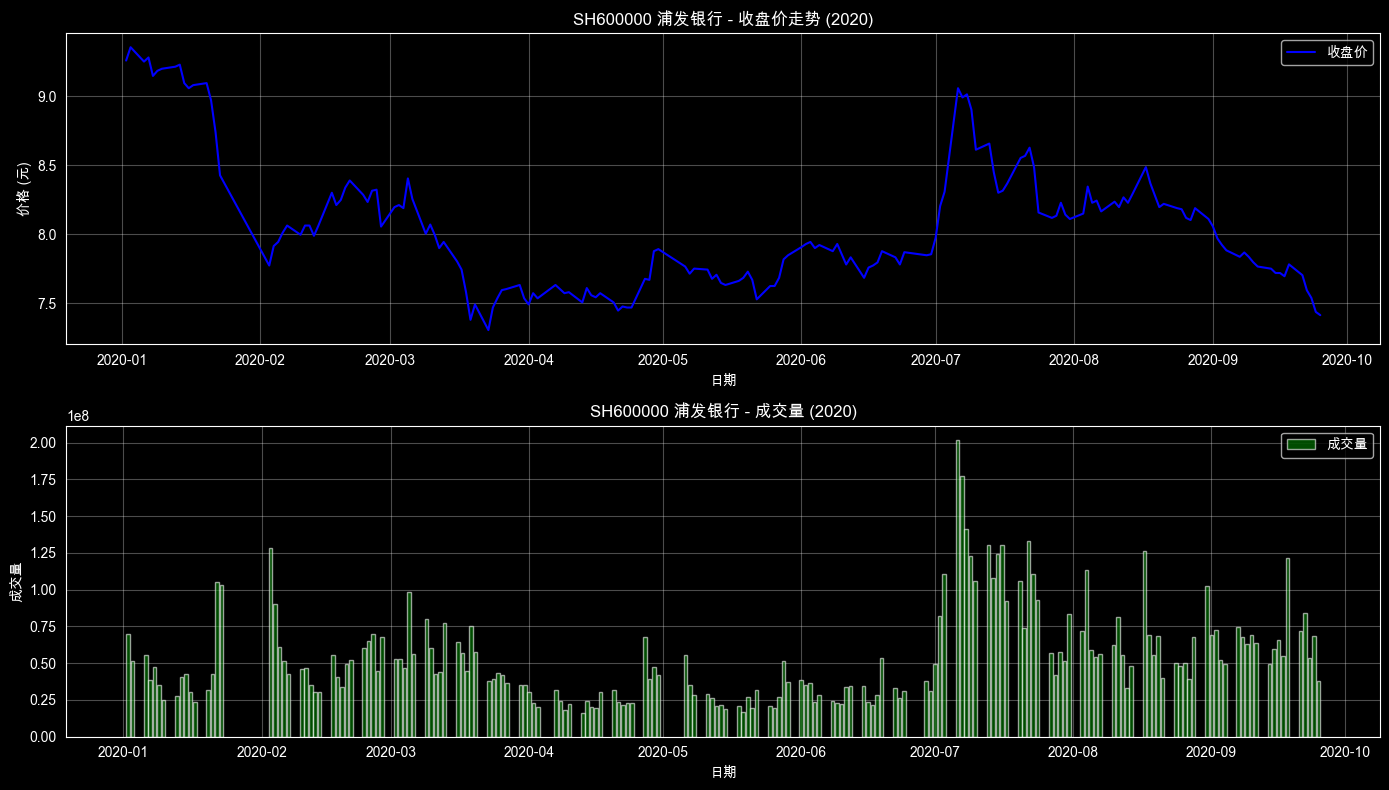

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 设置中文字体（如果遇到显示问题）
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 绘制收盘价走势
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 收盘价
ax1 = axes[0]
ax1.plot(df.index.get_level_values("datetime"), df["$close"], label="收盘价", color="blue")
ax1.set_title("SH600000 浦发银行 - 收盘价走势 (2020)")
ax1.set_xlabel("日期")
ax1.set_ylabel("价格 (元)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 成交量
ax2 = axes[1]
ax2.bar(df.index.get_level_values("datetime"), df["$volume"], label="成交量", color="green", alpha=0.6)
ax2.set_title("SH600000 浦发银行 - 成交量 (2020)")
ax2.set_xlabel("日期")
ax2.set_ylabel("成交量")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1.6 实践练习

### 练习目标

1. 安装 qlib 及依赖
2. 下载内置数据集（cn_data）
3. 初始化 qlib 并获取沪深300股票列表
4. 查询单只股票的收盘价数据

### 练习任务

In [15]:
# 任务1: 获取 2020年 沪深300 指数（SH000300）的收盘价数据
# 并计算年化收益率

# 你的代码

df_index = D.features(
    instruments=["SH000300"],  # 浦发银行 - 必须是列表
    fields=["$close", "$open", "$high", "$low", "$volume"],
    start_time="2020-01-01",
    end_time="2020-12-31",
    freq="day"
)

annual_return = (df_index['$close'].iloc[-1] / df_index['$close'].iloc[0]) ** (252 / len(df_index)) - 1
annual_return
# 提示:
# df_index = D.features(instruments=["SH000300"], fields=["$close"], start_time="2020-01-01", end_time="2020-12-31", freq="day")
# annual_return = (df_index['$close'].iloc[-1] / df_index['$close'].iloc[0]) ** (252 / len(df_index)) - 1

np.float32(0.14364159)

In [ ]:
# 任务2: 获取任意 5 只沪深300成分股 2020年的收盘价
# 并绘制价格对比图

# 你的代码



# 提示:
# 先获取沪深300成分股列表
# instruments_list = D.list_instruments(D.instruments(market="csi300"), as_list=True)
# df_stocks = D.features(
#     instruments=instruments_list[:5],
#     fields=["$close"],
#     start_time="2020-01-01",
#     end_time="2020-12-31",
#     freq="day"
# )

In [ ]:
# 任务3: 计算 2023年 每个交易日的涨跌幅
# 绘制 SH600000 的日收益率分布直方图

# 你的代码



# 提示:
# df['return'] = df['$close'].pct_change()
# df['return'].hist(bins=50)

## 1.7 本章小结

本章我们学习了：

1. **Qlib 定位**：AI 导向的量化投资平台
2. **系统架构**：Data、Model、Strategy、Backtest 四大模块
3. **环境搭建**：安装、数据下载、初始化
4. **基础 API**：
   - `qlib.init()` - 初始化
   - `D.calendar()` - 获取交易日历
   - `D.instruments()` - 获取股票列表
   - `D.features()` - 获取特征数据

### 关键 API 速查

```python
# 初始化
qlib.init(provider_uri="path/to/data", region="cn")

# 交易日历
calendar = D.calendar(freq="day")

# 股票列表
instruments = D.instruments(market="csi300")

# 特征数据
df = D.features(
    instruments="SH600000",          # 股票代码或市场
    fields=["$close", "$volume"],   # 字段列表
    start_time="2023-01-01",        # 开始时间
    end_time="2023-12-31",          # 结束时间
    freq="day"                       # 频率
)
```

### 下一章预告

下一章我们将深入学习 qlib 的数据系统，包括：
- 数据架构详解
- 核心数据 API 深入使用
- 数据缓存机制
- 表达式引擎